In [17]:
import json
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [18]:
RAW_PATH = Path("../data/raw/iowa_crash_data_raw.json")

with RAW_PATH.open("r", encoding="utf-8") as file:
    raw_data = json.load(file)

crashes = pd.DataFrame(
    feature["attributes"]
    for feature in raw_data["features"]
)

In [19]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,1421539200000,1421568000000,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,1422835200000,1422879480000,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,1423094400000,1423157100000,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,1422403200000,1422404160000,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,1423008000000,1423035300000,28,DELAWARE,5.0,1,1


In [20]:
crashes["CRASH_DATE"] = (
    pd.to_datetime(crashes["CRASH_DATE"], unit="ms")
    .dt.date 
)


crashes["CRASH_DATETIME"] = pd.to_datetime(
    crashes["CRASH_DATETIME"],
    unit="ms"
)

In [21]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,2015-01-18,2015-01-18 08:00:00,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,2015-02-02,2015-02-02 12:18:00,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,2015-02-05,2015-02-05 17:25:00,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,2015-01-28,2015-01-28 00:16:00,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,2015-02-04,2015-02-04 07:35:00,28,DELAWARE,5.0,1,1


In [22]:
crashes.describe()

,OBJECTID,CRASH_KEY,CRASH_DATETIME,COUNTY_NUMBER,CSEV,WEATHER,CSRFCND
count,5.975160e+05,5.975160e+05,597516,597516.000000,597515.000000,597516.000000,597516.000000
mean,1.961700e+07,1.853585e+10,2020-06-13 22:21:27.531000,58.269581,4.570017,11.031264,10.611210
min,8.931903e+06,2.015836e+09,2015-01-01 00:13:00,0.000000,1.000000,1.000000,1.000000
25%,1.962886e+07,2.017101e+10,2017-09-27 15:03:00,32.000000,4.000000,1.000000,1.000000
50%,1.977824e+07,2.020117e+10,2020-05-22 20:19:30,64.000000,5.000000,1.000000,1.000000
75%,1.992762e+07,2.023135e+10,2023-03-08 17:06:00,78.000000,5.000000,2.000000,2.000000
max,2.462362e+07,2.025156e+10,2025-12-31 23:19:00,99.000000,5.000000,99.000000,99.000000
std,3.847931e+06,5.252000e+09,NaN,27.337291,0.791000,25.032582,24.738789


In [23]:
crashes.shape

(597516, 9)

In [24]:
crashes.columns

Index(['OBJECTID', 'CRASH_KEY', 'CRASH_DATE', 'CRASH_DATETIME',
       'COUNTY_NUMBER', 'COUNTY_NAME', 'CSEV', 'WEATHER', 'CSRFCND'],
      dtype='str')

In [25]:
print("OBJECTID unique:", crashes["OBJECTID"].is_unique)
print("Duplicated OBJECTIDs:", crashes["OBJECTID"].duplicated().sum())

OBJECTID unique: True
Duplicated OBJECTIDs: 0


In [26]:
crashes["CRASH_DATE"] = (
    pd.to_datetime(crashes["CRASH_DATE"], unit="ms")
    .dt.date 
)


crashes["CRASH_DATETIME"] = pd.to_datetime(
    crashes["CRASH_DATETIME"],
    unit="ms"
)

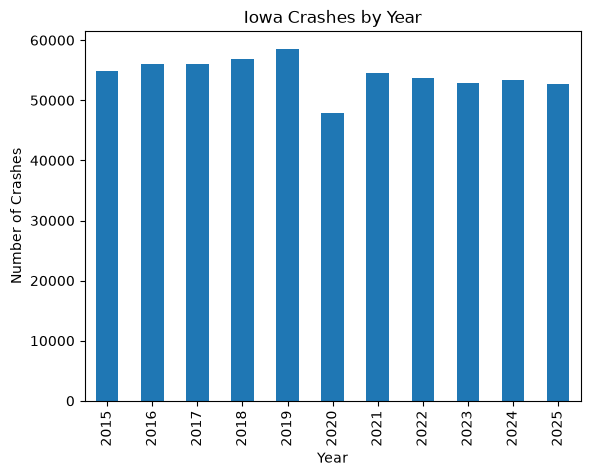

In [27]:
year_counts = (
    crashes["CRASH_DATE"]
    .apply(lambda date: date.year)
    .value_counts()
    .sort_index()
)


year_counts.plot(
    kind="bar",
    xlabel="Year",
    ylabel="Number of Crashes",
    title="Iowa Crashes by Year"
)

plt.show()

In [28]:
print(crashes.isna().sum())
print(
    (
        (crashes["COUNTY_NUMBER"] == 0)
        & crashes["COUNTY_NAME"].isna()
    ).sum()
)


OBJECTID             0
CRASH_KEY            0
CRASH_DATE           0
CRASH_DATETIME       0
COUNTY_NUMBER        0
COUNTY_NAME       1073
CSEV                 1
WEATHER              0
CSRFCND              0
dtype: int64
1073


In [29]:
crashes[crashes["COUNTY_NUMBER"] == 0]

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
61966,19541446,2.023134e+10,2023-01-23,2023-01-23 06:30:00,0,NaN,5.0,2,3
67975,19547455,2.023136e+10,2023-04-13,2023-04-13 12:03:00,0,NaN,5.0,1,1
68364,19547844,2.023136e+10,2023-03-27,2023-03-27 06:00:00,0,NaN,5.0,1,10
71631,19551111,2.023136e+10,2023-05-02,2023-05-02 18:45:00,0,NaN,5.0,1,1
71633,19551113,2.023136e+10,2023-05-11,2023-05-11 23:30:00,0,NaN,5.0,5,2
...,...,...,...,...,...,...,...,...,...
592405,24618506,2.024146e+10,2024-11-23,2024-11-23 00:00:00,0,NaN,5.0,1,1
592603,24618704,2.024146e+10,2024-11-26,2024-11-26 07:45:00,0,NaN,5.0,1,1
592803,24618904,2.024146e+10,2024-07-23,2024-07-23 12:00:00,0,NaN,5.0,77,77
593966,24620067,2.024146e+10,2024-12-05,2024-12-05 18:15:00,0,NaN,5.0,1,1
